In [1]:
from sklearn import metrics

In [2]:
C='Cat'
D='Dog'
F='Fox'

In [4]:
y_true = [C,C,C,C,C,C, F,F,F,F,F,F,F,F,F,F, D,D,D,D,D,D,D,D,D]
y_pred = [C,C,C,C,D,F, C,C,C,C,C,C,D,D,F,F, C,C,C,D,D,D,D,D,D]

print(metrics.confusion_matrix(y_true, y_pred))
print(metrics.classification_report(y_true, y_pred, digits=3))

[[4 1 1]
 [3 6 0]
 [6 2 2]]
              precision    recall  f1-score   support

         Cat      0.308     0.667     0.421         6
         Dog      0.667     0.667     0.667         9
         Fox      0.667     0.200     0.308        10

    accuracy                          0.480        25
   macro avg      0.547     0.511     0.465        25
weighted avg      0.581     0.480     0.464        25



### Isolation Forest

In [26]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

In [27]:
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [28]:
ifa = IsolationForest(contamination=0.1)
ifa.fit(X_train)

IsolationForest(contamination=0.1)

In [29]:
y_pred_train = ifa.predict(X_train)
y_pred_test = ifa.predict(X_test)

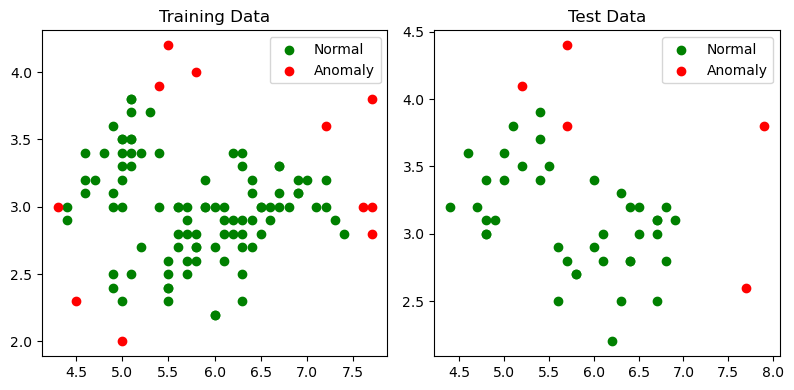

In [32]:
def create_scatter_plots(X1, y1, title1, X2, y2, title2):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].scatter(X1[y1==1, 0], X1[y1==1, 1], color='green', label='Normal')
    axes[0].scatter(X1[y1==-1, 0], X1[y1==-1, 1], color='red', label='Anomaly')
    axes[0].set_title(title1)
    axes[0].legend()

    axes[1].scatter(X2[y2==1, 0], X2[y2==1, 1], color='green', label='Normal')
    axes[1].scatter(X2[y2==-1, 0], X2[y2==-1, 1], color='red', label='Anomaly')
    axes[1].set_title(title2)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

create_scatter_plots(X_train, y_pred_train, 'Training Data', X_test, y_pred_test, 'Test Data')

### DBSCAN anomaly detection

In [5]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

In [6]:
X,y = make_circles(n_samples=750, factor=0.3, noise=0.1)

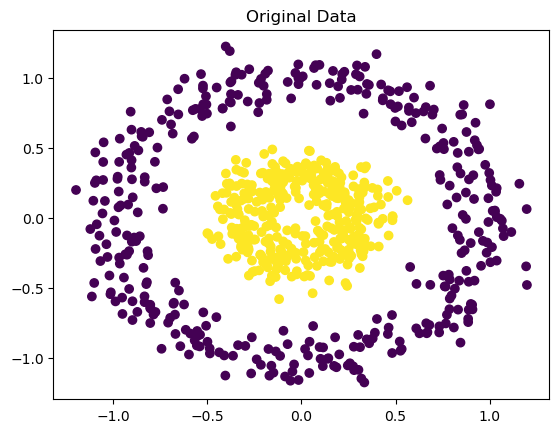

In [23]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.title('Original Data')
plt.show()

In [8]:
dbscan = DBSCAN(eps=0.10)

In [9]:
dbscan.fit_predict(X)

array([ 0,  1,  1,  1,  2,  1,  3,  1,  1,  4,  1,  1,  1,  2,  1, -1,  7,
        3,  1,  1,  1,  3,  1,  5,  1,  6,  1,  4,  2,  1,  2,  2,  1,  7,
        6,  1,  1,  1,  1,  1,  1,  1,  1,  1,  6,  6,  1,  4,  6,  6,  4,
        6,  5,  4,  4, -1,  1,  4,  2,  3,  2,  1,  1,  2,  4,  6,  1,  0,
       -1,  4,  1,  1,  0,  0,  1,  1,  1, -1,  1,  1,  1,  5,  2,  1,  1,
        1,  1,  3,  1,  2,  3,  3,  1,  2,  4,  1,  1,  1,  1,  6,  1,  2,
        1,  3,  1,  3,  2,  1,  1,  1,  1,  6,  8,  0,  1,  6,  1,  6,  3,
        0,  1,  4,  2,  3,  1,  5,  1,  1,  1,  1,  6,  0,  1,  1, -1,  5,
        5, -1,  1,  1,  0,  0,  1,  1,  1,  1,  1,  1,  1,  5,  6,  5,  1,
        1,  5, -1,  0,  1,  1,  1,  1,  1,  1,  3,  1,  6,  3,  1,  3,  1,
        3,  1,  6,  1,  3,  8,  8,  1,  1,  1,  1,  1,  3,  1,  0,  1, -1,
        0,  1,  1,  1, -1,  1,  1,  0,  1,  1, -1,  1, -1,  1,  1, -1,  1,
       -1,  1,  6,  1,  1,  1,  0,  1,  1,  1,  5,  1,  1, -1,  0,  1,  0,
        0, -1,  2, -1,  1

In [24]:
l = dbscan.labels_

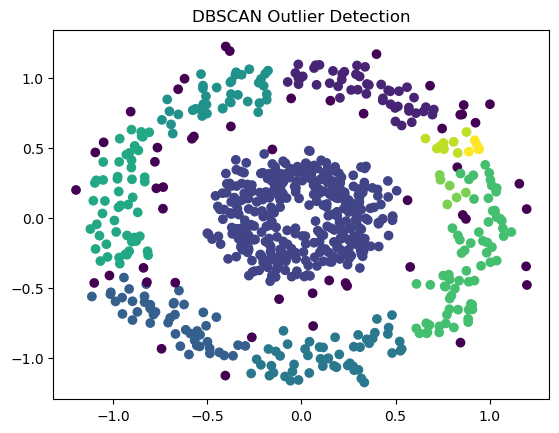

In [22]:
plt.scatter(X[:,0], X[:,1], c=dbscan.labels_)
plt.title('DBSCAN Outlier Detection')
plt.show()

### Local Outlier Factor

In [13]:
from sklearn.neighbors import LocalOutlierFactor

In [15]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(X)
y_pred

array([ 1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1, -1, -1,  1,  1,  1, -1,  1,  1, -1,  1, -1,  1,  1,  1,  1, -1,
       -1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1, -1,  1,
       -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1

In [19]:
scores = lof.negative_outlier_factor_
outliers = X[y_pred == -1]

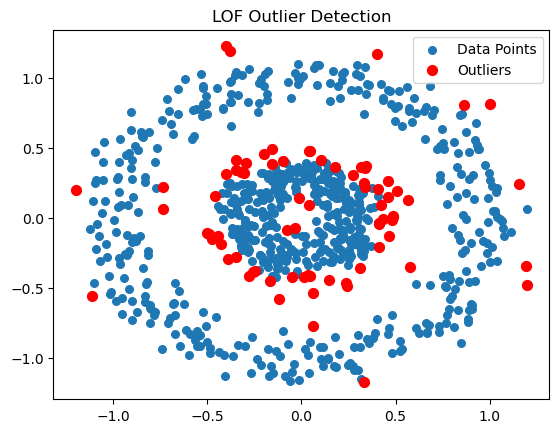

In [21]:
plt.scatter(X[:,0], X[:,1], s=30, label='Data Points')
plt.scatter(outliers[:,0], outliers[:,1], color='r', s=50, label='Outliers')
plt.title('LOF Outlier Detection')
plt.legend()
plt.show()